# Modeling and Simulation - Bike Share System
Introduction to Modeling and Simulation

**What is a Model?**

In the context of science and engineering, a model is a simplified representation of a real-world system. The goal of a model is to capture the essential features of the system in a way that allows us to predict its behavior. Models can be mathematical, physical, or computational.

For example, imagine we are trying to understand a bike share system in a city. A city might have a number of bike stations, each with a certain number of bikes. People can borrow bikes from any station and return them to any other station. Our task is to model this system in a simplified form to understand how well the system works and how to make it more efficient.

**What is a Simulation?**

A simulation is a process of using a model to study the behavior of a system over time. Simulations are often used when it's difficult or impossible to study the actual system directly. By simulating a system, we can ask "what if" questions and test how the system responds to different conditions.

<div style="display: flex;">
    <div>
        <img src="https://drive.google.com/uc?export=view&id=1jkKAp3Z1Dw23aX7rqFcamRJn18sZgnsi" alt="Description" width="150" style="float: right; margin-left: 20px;">
    </div>
</div>

In this lab, we will use Python to build a simple simulation of a bike share system and study how it behaves under different conditions.

**Defining the System**

Imagine a city that has set up a bike-sharing program. There are multiple stations scattered across the city, each station equipped with bikes and docks.

Stations are the places where the bikes are stored. Each station has a limited number of bikes and a limited number of docks (parking spots for bikes). Some stations might be busier than others, and the number of bikes can vary from station to station at different times of the day.

Bikes are what people use for transport. We don't need to track each individual bike (for simplicity), but we do care about how many bikes are available at each station.

Trips represent the movement of bikes. A trip occurs when a person picks up a bike from one station and drops it off at another. The goal of the system is to ensure that bikes are available when people need them, and that there are enough empty docks when people return the bikes.


---



The Challenge:
Even in a simple bike-sharing system, you still need to manage the following:

* Bike Availability: A station can't provide a bike if it's empty.
* Dock Availability: A station can't accept a returned bike if all docks are full.
* Trips: As bikes move from one station to another, we track where they are picked up and dropped off.

### Basic Python Modelling

In [5]:
# Model your bike system using basic python below

class Bike:
    def __init__(self, bike_id):
        self.bike_id = bike_id
        self.is_rented = False

    def rent(self):
        if not self.is_rented:
            self.is_rented = True
            return True
        return False

    def return_bike(self):
        if self.is_rented:
            self.is_rented = False
            return True
        return False

    def __str__(self):
        status = "Rented" if self.is_rented else "Available"
        return f"Bike {self.bike_id}: {status}"

class Station:
    def __init__(self, name, capacity):
        self.name = name
        self.capacity = capacity
        self.bikes = []  

    def dock_bike(self, bike):
        if len(self.bikes) < self.capacity and not bike.is_rented:
            self.bikes.append(bike)
            return True
        return False

    def release_bike(self, bike_id):
        for bike in self.bikes:
            if bike.bike_id == bike_id and not bike.is_rented:
                bike.rent()
                self.bikes.remove(bike)
                return bike
        return None

    def __str__(self):
        return f"Station {self.name}: {len(self.bikes)}/{self.capacity} bikes"

### Python Classes Introduction

In [16]:
# Defining a Class: A class is defined using the class keyword
class MyClass:
    pass  # This creates an empty class

**Constructor** (__init__ method): The __init__ method is a special function that gets called when an object (instance of the class) is created. It initializes the attributes of the object.

In [17]:
class Person:
    def __init__(self, name, age):
        self.name = name  # Attribute
        self.age = age    # Attribute

# self refers to the current instance of the class.
# Attributes like name and age are created and initialized in the constructor.

Creating an Object (Instance): To create an instance (object) of a class, you call the class as if it were a function:

In [20]:
person1 = Person("Alice", 30)  # Creates a Person object with name "Alice" and age 30
print(person1.name)  # Output: Alice

Alice


Methods: Methods are functions defined inside a class that operate on the instance’s data (attributes).

In [23]:
class Person:
    def __init__(self, name, age):
        self.name = name
        self.age = age

    def greet(self):
        print(f"Hello, my name is {self.name} and I'm {self.age} years old.")

person1 = Person("Alice", 30)
person1.greet()  # Output: Hello, my name is Alice and I'm 30 years old.

Hello, my name is Alice and I'm 30 years old.


Let's write our bikesharing system using Python classes now, allowing us to generalize to any number of stations.

In [ ]:
# Write the system using Python Classes
class BikeSharingSystem:
    def __init__(self):
        self.stations = {}
        self.bike_locations = {}  
        self.bikes = {}

    def add_station(self, name, capacity):
        if name not in self.stations:
            self.stations[name] = Station(name, capacity)

    def add_bike(self, bike_id, station_name):
        if station_name in self.stations:
            bike = Bike(bike_id)
            if self.stations[station_name].dock_bike(bike):
                self.bikes[bike_id] = bike
                self.bike_locations[bike_id] = (None, station_name)
                return True
        return False

    def release_bike(self, station_name, bike_id):
        if station_name in self.stations and bike_id in self.bikes:
            bike = self.stations[station_name].release_bike(bike_id)
            if bike:
                self.bike_locations[bike_id] = (station_name, None)
                return bike
        return None

    def dock_bike(self, station_name, bike):
        if station_name in self.stations:
            bike.return_bike()  
            if self.stations[station_name].dock_bike(bike):
                self.bike_locations[bike.bike_id] = (self.bike_locations[bike.bike_id][0], station_name)
                return True
        return False

    def get_bike_location(self, bike_id):
        return self.bike_locations.get(bike_id, None)

    def __str__(self):
        return "\n".join(str(station) for station in self.stations.values())

class Test:
    @staticmethod
    def run():
        system = BikeSharingSystem()
        system.add_station("UPT", 3)
        system.add_station("Center", 2)
        system.add_bike(1, "UPT")
        system.add_bike(2, "UPT")
        system.add_bike(3, "Center")
        print("Initial system:")
        print(system)
        print("\n")
        # Release bike 1 from UPT
        bike = system.release_bike("UPT", 1)
        print(f"Bike 1 released from UPT: {bike}")
        # Dock bike 1 at Center
        docked = system.dock_bike("Center", bike)
        print(f"Bike 1 docked at Center: {docked}")
        print("\nSystem after moving bike 1 from UPT to Center:")
        print(f"\n{system}\n")
        print("Bike 1 location history:", system.get_bike_location(1))

Test.run()

Initial system:
Station UPT: 2/3 bikes
Station Center: 1/2 bikes


Bike 1 released from UPT: Bike 1: Rented
Bike 1 docked at Center: True

System after moving bike 1 from UPT to Center:

Station UPT: 1/3 bikes
Station Center: 2/2 bikes

Bike 1 location history: ('UPT', 'Center')


### Introducing Probabilities and Time


In this extended version of the bike-sharing system, we introduce probabilities and time to simulate trips between stations over a set period. We aim to model the likelihood of bike movement between stations at each minute. We will use the following probabilities:

* 0.3 probability: On average, there is a 30% chance per minute that a bike will be taken from the UPT station to the Center station.
* 0.5 probability: On average, there is a 50% chance per minute that a bike will be taken from the Center station to the UPT station.

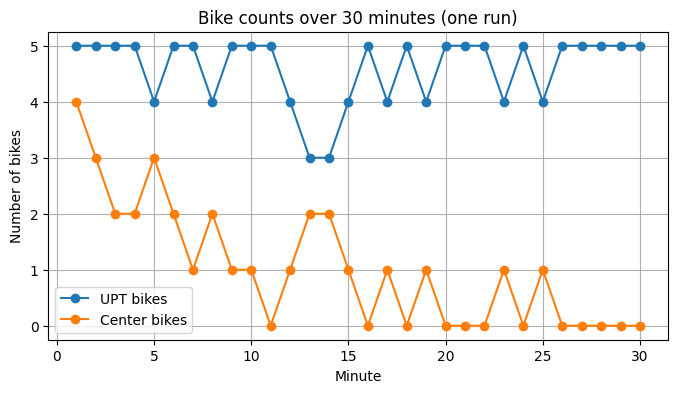

Unhappy events this run: {'pickup_failed': 1, 'return_failed': 4}
Over 50 runs (30 min each): avg pickup_failed = 2.76, avg return_failed = 3.40
Estimated per-hour unhappy (scale x2): pickup_failed ≈ 5.52, return_failed ≈ 6.80


In [12]:
# Extend implementation to simulate a couple of times what happens with the system in a 30 minutes period
# Write code below
# ...existing code...
import random
import matplotlib.pyplot as plt
import statistics

def make_initial_system():
    sys = BikeSharingSystem()
    sys.add_station("UPT", 5)
    sys.add_station("Center", 10)
    sys.add_bike(1, "UPT")
    sys.add_bike(2, "UPT")
    sys.add_bike(3, "Center")
    sys.add_bike(6, "Center")
    sys.add_bike(8, "Center")
    sys.add_bike(9, "Center")
    sys.add_bike(10, "Center")
    sys.add_bike(12, "UPT")
    sys.add_bike(14, "UPT")
    return sys

def simulate_once(minutes=30, p_up_to_center=0.3, p_center_to_up=0.5):
    system = make_initial_system()
    history = {"UPT": [], "Center": []}
    unhappy = {"pickup_failed": 0, "return_failed": 0}

    for minute in range(minutes):
        # attempt UPT -> Center (one attempt per minute)
        if random.random() < p_up_to_center:
            # try to take any available bike from UPT
            if len(system.stations["UPT"].bikes) == 0:
                unhappy["pickup_failed"] += 1
            else:
                bike = system.stations["UPT"].bikes[0]
                bike = system.release_bike("UPT", bike.bike_id)
                if bike is None:
                    unhappy["pickup_failed"] += 1
                else:
                    # try docking at center
                    if not system.dock_bike("Center", bike):
                        unhappy["return_failed"] += 1
                        # bike remains rented (not returned)

        # attempt Center -> UPT
        if random.random() < p_center_to_up:
            if len(system.stations["Center"].bikes) == 0:
                unhappy["pickup_failed"] += 1
            else:
                bike = system.stations["Center"].bikes[0]
                bike = system.release_bike("Center", bike.bike_id)
                if bike is None:
                    unhappy["pickup_failed"] += 1
                else:
                    if not system.dock_bike("UPT", bike):
                        unhappy["return_failed"] += 1

        # record counts
        history["UPT"].append(len(system.stations["UPT"].bikes))
        history["Center"].append(len(system.stations["Center"].bikes))

    return history, unhappy

# Run one example 30-minute simulation and plot
hist, unhappy = simulate_once(minutes=30, p_up_to_center=0.3, p_center_to_up=0.5)
minutes = list(range(1, len(hist["UPT"]) + 1))

plt.figure(figsize=(8,4))
plt.plot(minutes, hist["UPT"], marker='o', label="UPT bikes")
plt.plot(minutes, hist["Center"], marker='o', label="Center bikes")
plt.xlabel("Minute")
plt.ylabel("Number of bikes")
plt.title("Bike counts over 30 minutes (one run)")
plt.legend()
plt.grid(True)
plt.show()

print("Unhappy events this run:", unhappy)

# Run 50 simulations and compute average unhappy events per 30-min run and per hour
runs = 50
tot_pickup_failed = []
tot_return_failed = []
for _ in range(runs):
    _, u = simulate_once(minutes=30, p_up_to_center=0.3, p_center_to_up=0.5)
    tot_pickup_failed.append(u["pickup_failed"])
    tot_return_failed.append(u["return_failed"])

avg_pickup_30 = statistics.mean(tot_pickup_failed)
avg_return_30 = statistics.mean(tot_return_failed)
# scale to per hour (60 minutes) by multiplying by 2
print(f"Over {runs} runs (30 min each): avg pickup_failed = {avg_pickup_30:.2f}, avg return_failed = {avg_return_30:.2f}")
print(f"Estimated per-hour unhappy (scale x2): pickup_failed ≈ {avg_pickup_30*2:.2f}, return_failed ≈ {avg_return_30*2:.2f}")
# ...existing code...

### Save logs and plot data for analysis

To perform some analysis and visualize the results of the bike-sharing simulation, we can record the number of bikes at each station over time and then plot this data using the matplotlib library. This will help us understand how the bike availability at each station changes over time based on the probabilities.

In [51]:
# Save history at each minute and add plotting of said history
# Write code below


### Analyze events - Unhappy customers

Every time a rider can not get his bike because of the station being empty or being unable to return his bike to target station because of it being full, he will leave unhappy. We can track the number of times this occurs by simulating our system multiple times. We can vary the system variable and check average number of dissatisfied customers per hour for each of our setups. E.g. we leave more bikes in circulation, less bikes in circulation, we increase the number of max bike slots per station, etc.

In [50]:
# Write code to check average number of dissatisfied customer events over a sample size of 50 simulations, 30 minutes each.
# Vary any of the system variables and analyze the impact
